# Imports and set constants

In [50]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from PIL import Image
from collections import defaultdict
from IPython.display import clear_output
from sklearn.model_selection import train_test_split

from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import Sampler, DataLoader, Subset


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_STATE = 42

# Data

In [51]:
class PKBatchSampler(Sampler):
    def __init__(self, labels, p_classes: int, k_samples: int, batches_per_epoch: int):
        self.labels = torch.as_tensor(labels)
        self.p = p_classes
        self.k = k_samples
        self.batches_per_epoch = batches_per_epoch

        self.class_to_indices = defaultdict(list)
        for idx, y in enumerate(self.labels.tolist()):
            self.class_to_indices[y].append(idx)

        self.classes = list(self.class_to_indices.keys())
        if len(self.classes) < self.p:
            raise ValueError(f"Need at least {self.p} classes, got {len(self.classes)}")

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            chosen_classes = random.sample(self.classes, self.p)
            batch = []

            for c in chosen_classes:
                idxs = self.class_to_indices[c]
                # если в классе меньше K объектов, добираем с повторением
                if len(idxs) >= self.k:
                    picked = random.sample(idxs, self.k)
                else:
                    picked = random.choices(idxs, k=self.k)
                batch.extend(picked)

            random.shuffle(batch)
            yield batch


In [52]:
transform = transforms.ToTensor()
full_train_ds = MNIST(root="data", train=True, download=True, transform=transform)  # 60k
test_ds = MNIST(root="data", train=False, download=True, transform=transform)       # 10k

# 2) Стратифицированный split train/val из train части MNIST
all_indices = np.arange(len(full_train_ds))
all_labels = full_train_ds.targets.numpy()

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=10_000,
    random_state=42,
    stratify=all_labels,
)

train_ds = Subset(full_train_ds, train_idx)
val_ds = Subset(full_train_ds, val_idx)

# 3) PK sampler только для train
train_labels = full_train_ds.targets[train_idx]  # метки только train subset
p, k = 10, 500
steps_per_epoch = len(train_ds) // (p * k)

train_batch_sampler = PKBatchSampler(
    labels=train_labels,          # важно: labels длины len(train_ds)
    p_classes=p,
    k_samples=k,
    batches_per_epoch=steps_per_epoch
)

# 4) DataLoader'ы
train_loader = DataLoader(
    train_ds,
    batch_sampler=train_batch_sampler,   # без batch_size/shuffle
    pin_memory=True,
    num_workers=2,
)

val_loader = DataLoader(
    val_ds,
    batch_size=4096,
    shuffle=False,
    pin_memory=True,
    num_workers=2,
)

test_loader = DataLoader(
    test_ds,
    batch_size=4096,
    shuffle=False,
    pin_memory=True,
    num_workers=2,
)

In [53]:
class SuperModel(nn.Module):
    def __init__(self, emb_dim: int, hide_dim: int):
        super().__init__()

        self.emb_dim = emb_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 4, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(4, 8, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.projection = nn.Linear(8, emb_dim)
        
        self.head = nn.Sequential(
            nn.Linear(emb_dim, hide_dim),
            nn.ReLU(),
            nn.Linear(hide_dim, 10)
        )
    
    def forward(self, image: torch.Tensor):
        features = self.encoder(image)
        features = features.flatten(1)
        embedding = self.projection(features)
        logits = self.head(embedding)
        return embedding, logits

In [54]:
class TripletLoss(nn.Module):
    def __init__(self, margin: float):
        super().__init__()
        self.margin = margin

    def forward(self, emb: torch.Tensor, target: torch.Tensor):
        # emb: [B, D]
        emb = F.normalize(emb, p=2, dim=1)
        dist = self.distance(emb)

        positive_mask = (target.unsqueeze(0) == target.unsqueeze(1))
        negative_mask = ~positive_mask
        positive_mask.fill_diagonal_(False)

        pos_dist = dist.masked_fill(~positive_mask, -1e9).max(dim=1).values
        neg_dist = dist.masked_fill(~negative_mask, 1e9).min(dim=1).values

        loss = F.relu(pos_dist - neg_dist + self.margin)
        has_pos = positive_mask.any(dim=1)
        has_neg = negative_mask.any(dim=1)
        valid = has_pos & has_neg
        if valid.any():
            return loss[valid].mean()

        # если батч невалидный (например, все одного класса)
        return emb.new_tensor(0.0, requires_grad=True)

    def distance(self, emb: torch.Tensor):
        dot = emb @ emb.T
        sq = torch.diag(dot)
        dist = sq.unsqueeze(1) - 2 * dot + sq.unsqueeze(0)
        return dist.clamp_min(1e-12)

In [55]:
def train_one_epoch(
    model: nn.Module, 
    dataloader: DataLoader,
    triplet_criterion: nn.Module,
    cls_criterion,
    weight: float,
    optimizer: torch.optim.Optimizer,
    scheduler,
    device: str
):
    model.train()

    total_loss_sum = 0.0
    triplet_loss_sum = 0.0
    cls_loss_sum = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        embs, logits = model(images)
        triplet_loss = triplet_criterion(embs, targets)
        cls_loss = cls_criterion(logits, targets)

        loss = (1 - weight) * cls_loss + weight * triplet_loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss_sum += loss.item()
        triplet_loss_sum += triplet_loss.item()
        cls_loss_sum += cls_loss.item()
        
    return {
        "loss": total_loss_sum / len(dataloader),
        "triplet_loss": triplet_loss_sum / len(dataloader),
        "cls_loss": cls_loss_sum / len(dataloader)
    }


@torch.no_grad()
def validate_one_epoch(
    model,
    dataloader,
    triplet_criterion: nn.Module,
    cls_criterion,
    weight: float,
    device
):
    model.eval()

    min_loss = 1e9
    total_loss_sum = 0.0
    triplet_loss_sum = 0.0
    cls_loss_sum = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)

        embs, logits = model(images)
        triplet_loss = triplet_criterion(embs, targets)
        cls_loss = cls_criterion(logits, targets)

        loss = (1 - weight) * cls_loss + weight * triplet_loss
        total_loss_sum += loss.item()
        triplet_loss_sum += triplet_loss.item()
        cls_loss_sum += cls_loss.item()

        if loss < min_loss:
            checkpoint = {
            "model_state_dict": model.state_dict(),
                "best_val_loss": loss,
            }

            torch.save(checkpoint, "/kaggle/working/best.pt")
            min_loss = loss
        
    return {
        "loss": total_loss_sum / len(dataloader),
        "triplet_loss": triplet_loss_sum / len(dataloader),
        "cls_loss": cls_loss_sum / len(dataloader)
    }


def update_stats(stats, train_stat, val_stat):
    stats["train_loss"].append(train_stat["loss"])
    stats["train_loss_cls"].append(train_stat["cls_loss"])
    stats["train_loss_tri"].append(train_stat["triplet_loss"])
    stats["val_loss"].append(val_stat["loss"])
    stats["val_loss_cls"].append(val_stat["cls_loss"])
    stats["val_loss_tri"].append(val_stat["triplet_loss"])
    return stats


def plot_history(history: dict):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Total loss
    axes[0].plot(epochs, history["train_loss"], label="train_total")
    axes[0].plot(epochs, history["val_loss"], label="val_total")
    axes[0].set_title("Total Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # 2) Classification loss
    axes[1].plot(epochs, history["train_loss_cls"], label="train_cls")
    axes[1].plot(epochs, history["val_loss_cls"], label="val_cls")
    axes[1].set_title("Classification Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # 3) Triplet loss
    axes[2].plot(epochs, history["train_loss_tri"], label="train_triplet")
    axes[2].plot(epochs, history["val_loss_tri"], label="val_triplet")
    axes[2].set_title("Triplet Loss")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def train(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    triplet_criterion,
    cls_criterion,
    weight,
    device,
    epochs
):
    history = {
        "train_loss": [],
        "train_loss_cls": [],
        "train_loss_tri": [],
        "val_loss": [],
        "val_loss_cls": [],
        "val_loss_tri": [],
    }

    for epoch in tqdm(range(1, epochs + 1)):
        train_stat = train_one_epoch(
            model=model,
            dataloader=train_loader,
            triplet_criterion=triplet_criterion,
            cls_criterion=cls_criterion,
            weight=weight,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device
        )

        val_stat = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            triplet_criterion=triplet_criterion,
            cls_criterion=cls_criterion,
            weight=weight,
            device=device
        )

        history = update_stats(history, train_stat, val_stat)
        clear_output(wait=True)
        plot_history(history)
        print(
            f"Epoch {epoch}/{epochs}\n\n",
            f"train loss = {train_stat['loss']}\n",
            f"cls loss = {train_stat['cls_loss']}\n",
            f"triplet loss = {train_stat['triplet_loss']}\n\n",
            f"val loss = {val_stat['loss']}\n",
            f"cls loss = {val_stat['cls_loss']}\n",
            f"triplet loss = {val_stat['triplet_loss']}",
        )

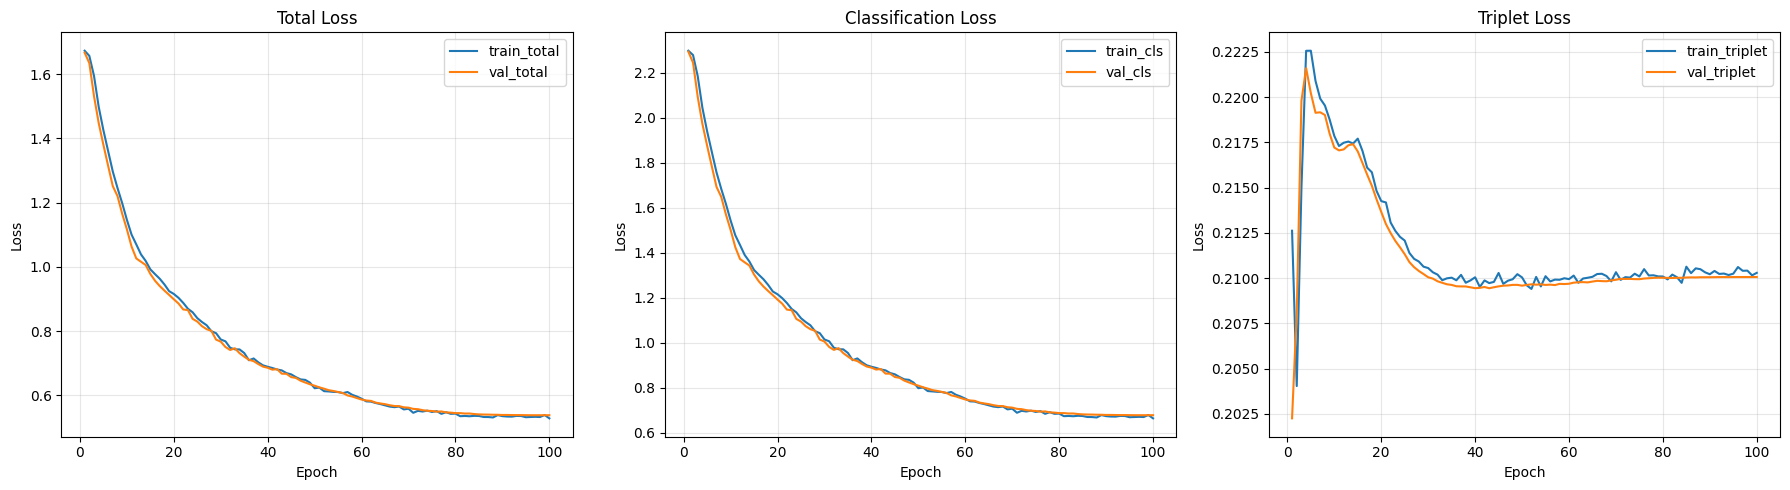

100%|██████████| 100/100 [07:29<00:00,  4.50s/it]

Epoch 100/100

 train loss = 0.5283490180969238
 cls loss = 0.6646581172943116
 triplet loss = 0.2102945014834404

 val loss = 0.5380689104398092
 cls loss = 0.6786430875460306
 triplet loss = 0.21006245414415994


In [57]:
model = SuperModel(32, 64)
model.to(DEVICE)
triplet_criterion = TripletLoss(margin=0.2)
cls_criterion = F.cross_entropy

epochs = 100
weight = 0.3
lr = 5e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    epochs*len(train_loader)
)

train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    triplet_criterion=triplet_criterion,
    cls_criterion=cls_criterion,
    weight=weight,
    device=DEVICE,
    epochs=epochs
)

In [58]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize

@torch.no_grad()
def evaluate_pr_f1_threshold(model, dataloader, device, num_classes=10):
    model.eval()

    all_probs = []
    all_targets = []

    for images, targets in dataloader:
        images = images.to(device, non_blocking=True)
        _, logits = model(images)
        probs = torch.softmax(logits, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_targets.append(targets.numpy())

    y_score = np.concatenate(all_probs, axis=0)      # [N, C]
    y_true = np.concatenate(all_targets, axis=0)     # [N]

    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))  # [N, C]

    # PR micro-average
    precision, recall, thresholds = precision_recall_curve(
        y_true_bin.ravel(), y_score.ravel()
    )
    ap_micro = average_precision_score(y_true_bin, y_score, average="micro")

    # F1 от порога (для каждого threshold из PR)
    f1_by_thr = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = np.argmax(f1_by_thr)
    best_thr = thresholds[best_idx]
    best_f1 = f1_by_thr[best_idx]

    # Проверка через явное порогование one-vs-rest
    y_pred_bin = (y_score >= best_thr).astype(np.uint8)
    best_f1_check = f1_score(y_true_bin.ravel(), y_pred_bin.ravel())

    print(f"AP (micro): {ap_micro:.6f}")
    print(f"Best threshold: {best_thr:.6f}")
    print(f"Best F1 (from PR points): {best_f1:.6f}")
    print(f"Best F1 (explicit thresholding): {best_f1_check:.6f}")

    # Графики
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(recall, precision, label=f"micro PR (AP={ap_micro:.4f})")
    axes[0].set_title("Precision-Recall Curve (Micro)")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(thresholds, f1_by_thr, label="F1 vs threshold")
    axes[1].axvline(best_thr, color="r", linestyle="--", label=f"best thr={best_thr:.4f}")
    axes[1].axhline(best_f1, color="g", linestyle="--", label=f"best F1={best_f1:.4f}")
    axes[1].set_title("F1 by Threshold (Micro, OvR)")
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("F1")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "ap_micro": ap_micro,
        "best_threshold": float(best_thr),
        "best_f1": float(best_f1),
    }

AP (micro): 0.867835
Best threshold: 0.377332
Best F1 (from PR points): 0.789414
Best F1 (explicit thresholding): 0.789414


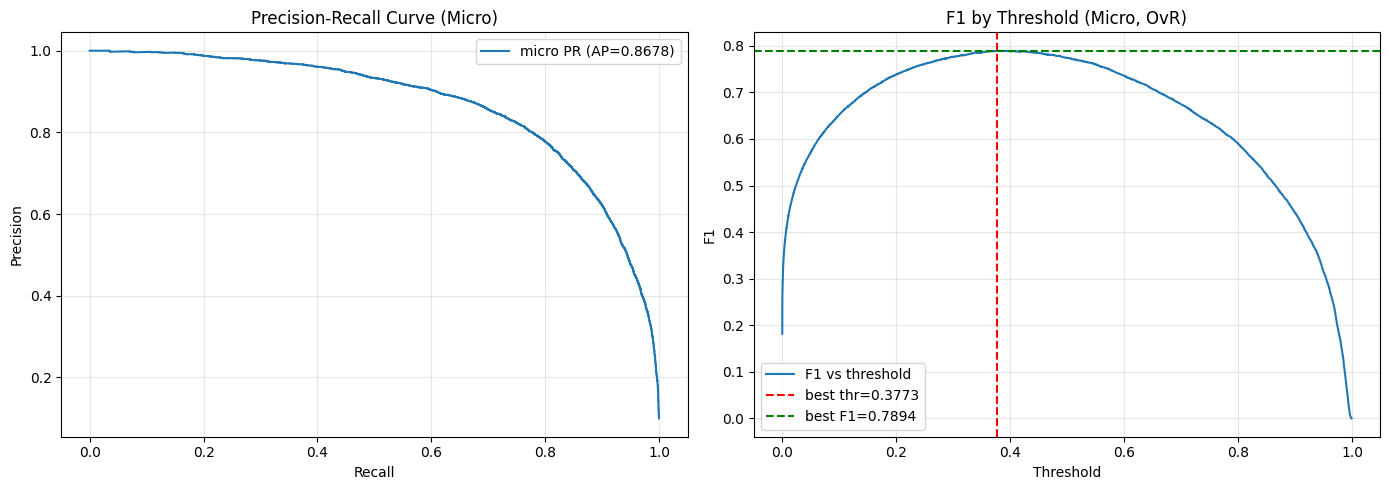

In [59]:
metrics = evaluate_pr_f1_threshold(model, test_loader, DEVICE, num_classes=10)